### Yellow Cab Chaos - EDA and Feature Engineering

Understand patterns in hourly demand and creating modeling-ready features

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from datetime import datetime

PROCESSED_PATH = "../data/processed/hourly_demand.parquet"
EXTERNAL_ZONES = "../data/external/taxi_zone_lookup.csv"

df = pd.read_parquet(PROCESSED_PATH)
zones = pd.read_csv(EXTERNAL_ZONES)

print(f"Loaded dataset shape: {df.shape}")
print(f"Date range: {df['pickup_date'].min()} → {df['pickup_date'].max()}")

Loaded dataset shape: (893448, 7)
Date range: 2007-12-05 → 2025-11-30


In [2]:
# Merge zone names & borough for better readability
df = df.merge(
    zones[['LocationID', 'Borough', 'Zone', 'service_zone']],
    left_on='zone_id',
    right_on='LocationID',
    how='left'
).drop(columns=['LocationID'])

print("Zone info merged.")
df.head(3)

Zone info merged.


,pickup_date,pickup_hour,zone_id,trip_count,avg_passengers,avg_distance,avg_fare,Borough,Zone,service_zone
0,2007-12-05,18,142,1,1.0,3.00,22.75,Manhattan,Lincoln Square East,Yellow Zone
1,2008-12-31,23,132,1,1.0,18.12,80.94,Queens,JFK Airport,Airports
2,2009-01-01,0,138,1,6.0,10.77,70.39,Queens,LaGuardia Airport,Airports


In [9]:
# Essential datetime features
df['pickup_date'] = pd.to_datetime(df['pickup_date'])          # make sure it's datetime
df['pickup_datetime'] = df['pickup_date'] + pd.to_timedelta(df['pickup_hour'], unit='h')

df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek
df['pickup_month']     = df['pickup_datetime'].dt.month
df['is_weekend']       = df['pickup_dayofweek'].isin([5, 6]).astype(int)
df['is_rush_hour']     = df['pickup_hour'].isin([7,8,9,16,17,18]).astype(int)

print("Datetime features:")
print(df[['pickup_date', 'pickup_hour', 'pickup_dayofweek', 'is_weekend', 'is_rush_hour']].head(8))

Datetime features:
  pickup_date  pickup_hour  pickup_dayofweek  is_weekend  is_rush_hour
0  2007-12-05           18                 2           0             1
1  2008-12-31           23                 2           0             0
2  2009-01-01            0                 3           0             0
3  2009-01-01            0                 3           0             0
4  2009-01-01            0                 3           0             0
5  2009-01-01            8                 3           0             1
6  2009-01-01           12                 3           0             0
7  2009-01-01           14                 3           0             0


Trip count distribution (log scale recommended):


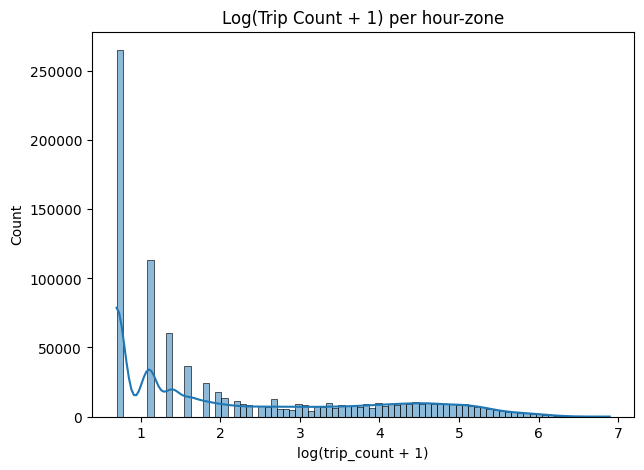

In [4]:
# Basic distributions
print("Trip count distribution (log scale recommended):")
plt.figure(figsize=(7, 5))
sns.histplot(np.log1p(df['trip_count']), bins=80, kde=True)
plt.title("Log(Trip Count + 1) per hour-zone")
plt.xlabel("log(trip_count + 1)")
plt.show()

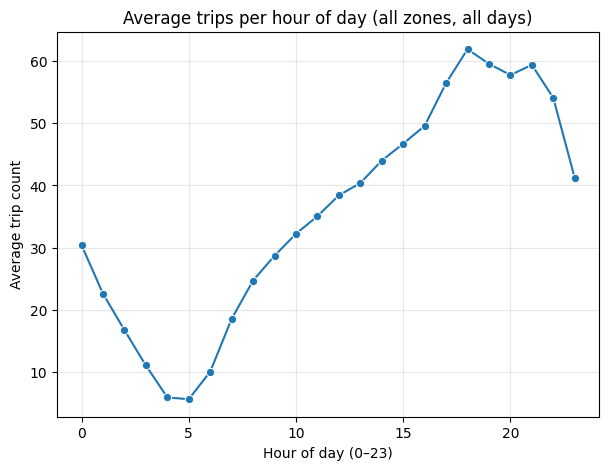

In [5]:
# Average demand by hour of day
hourly_profile = df.groupby('pickup_hour')['trip_count'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.lineplot(data=hourly_profile, x='pickup_hour', y='trip_count', marker='o')
plt.title("Average trips per hour of day (all zones, all days)")
plt.xlabel("Hour of day (0–23)")
plt.ylabel("Average trip count")
plt.grid(True, alpha=0.3)
plt.show()

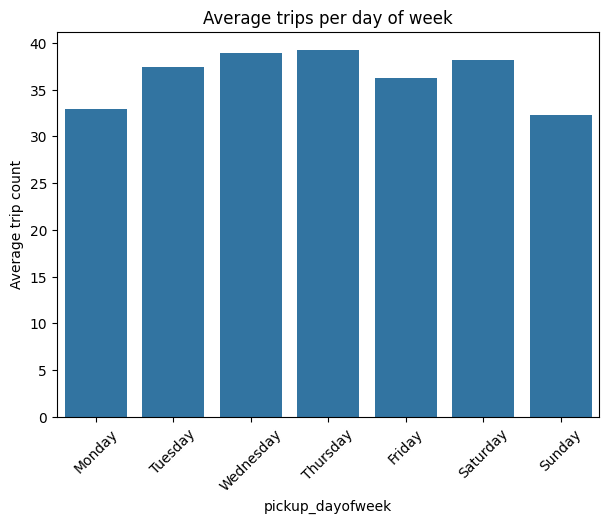

In [10]:
# Average demand by day of week
dow_profile = df.groupby('pickup_dayofweek')['trip_count'].mean().reset_index()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(7, 5))
sns.barplot(data=dow_profile, x='pickup_dayofweek', y='trip_count')
plt.xticks(ticks=range(7), labels=dow_names, rotation=45)
plt.title("Average trips per day of week")
plt.ylabel("Average trip count")
plt.show()

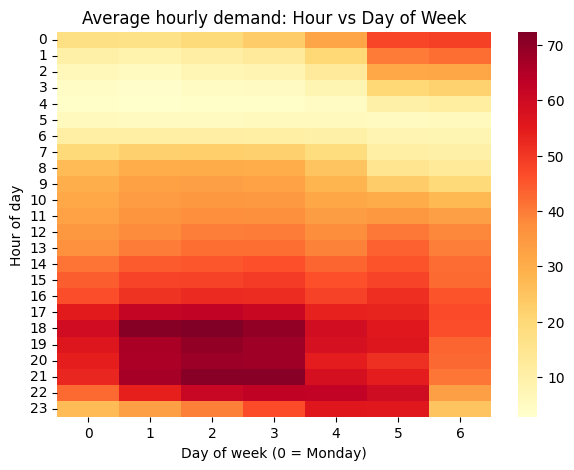

In [11]:
# Heatmap: hour vs day-of-week
heatmap_data = df.pivot_table(
    values='trip_count',
    index='pickup_hour',
    columns='pickup_dayofweek',
    aggfunc='mean'
)

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False)
plt.title("Average hourly demand: Hour vs Day of Week")
plt.xlabel("Day of week (0 = Monday)")
plt.ylabel("Hour of day")
plt.show()

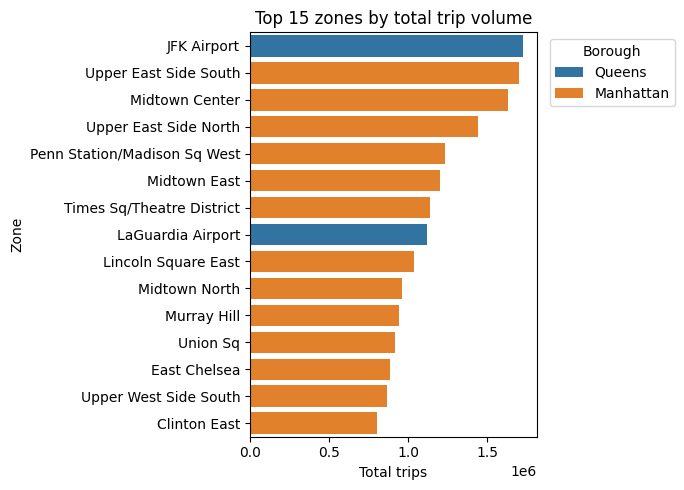

                            Zone    Borough  trip_count
0                    JFK Airport     Queens     1728925
1          Upper East Side South  Manhattan     1702498
2                 Midtown Center  Manhattan     1631023
3          Upper East Side North  Manhattan     1440445
4   Penn Station/Madison Sq West  Manhattan     1235394
5                   Midtown East  Manhattan     1201277
6      Times Sq/Theatre District  Manhattan     1140646
7              LaGuardia Airport     Queens     1120085
8            Lincoln Square East  Manhattan     1038988
9                  Midtown North  Manhattan      963778
10                   Murray Hill  Manhattan      943420
11                      Union Sq  Manhattan      915485
12                  East Chelsea  Manhattan      887002
13         Upper West Side South  Manhattan      864508
14                  Clinton East  Manhattan      802834


In [12]:
# Top 15 busiest zones (by total trips)
top_zones = df.groupby(['zone_id', 'Borough', 'Zone'])['trip_count'].sum().nlargest(15).reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=top_zones, x='trip_count', y='Zone', hue='Borough', dodge=False)
plt.title("Top 15 zones by total trip volume")
plt.xlabel("Total trips")
plt.legend(title="Borough", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print(top_zones[['Zone', 'Borough', 'trip_count']])

### Feature Engineering

In [15]:
# Feature Engineering

# 1. Is weekend
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(int)

# 2. Is rush hour (morning + evening peaks – rough definition)
df['is_rush_hour'] = df['pickup_hour'].isin([7,8,9,16,17,18]).astype(int)

# 3. US holidays (using holidays library)
us_holidays = holidays.US(years=df['pickup_date'].dt.year.unique())
df['is_holiday'] = df['pickup_date'].apply(lambda x: 1 if x in us_holidays else 0)

print(f"Holidays found: {df['is_holiday'].sum():,} rows")
print("Sample holidays:", list(us_holidays.items())[:5])

Holidays found: 23,938 rows
Sample holidays: [(datetime.date(2024, 1, 1), "New Year's Day"), (datetime.date(2024, 5, 27), 'Memorial Day'), (datetime.date(2024, 6, 19), 'Juneteenth National Independence Day'), (datetime.date(2024, 7, 4), 'Independence Day'), (datetime.date(2024, 9, 2), 'Labor Day')]


In [17]:
# Lagged features – previous 1, 24, 168 hours (1 day & 1 week lag)
#    → requires careful sorting and grouping

df = df.sort_values(['zone_id', 'pickup_date', 'pickup_hour'])

def add_lags(group, lags=[1, 24, 168]):
    for lag in lags:
        group[f'trip_count_lag_{lag}h'] = group['trip_count'].shift(lag)
    return group

df = df.groupby('zone_id', group_keys=False).apply(add_lags)

print("Lagged features added.")
print(df[['zone_id', 'pickup_date', 'pickup_hour', 'trip_count'] + [c for c in df.columns if 'lag' in c]].head(10))

Lagged features added.
      zone_id pickup_date  pickup_hour  trip_count  trip_count_lag_1h  \
625         1  2025-01-01            6           1                NaN   
1256        1  2025-01-01           13           1                1.0   
1365        1  2025-01-01           14           1                1.0   
1576        1  2025-01-01           16           1                1.0   
1759        1  2025-01-01           18           1                1.0   
3423        1  2025-01-02           12           1                1.0   
3553        1  2025-01-02           13           1                1.0   
3670        1  2025-01-02           14           1                1.0   
3923        1  2025-01-02           16           2                1.0   
4036        1  2025-01-02           17           1                2.0   

      trip_count_lag_24h  trip_count_lag_168h  
625                  NaN                  NaN  
1256                 NaN                  NaN  
1365                 NaN     

C:\Users\WELCOME\AppData\Local\Temp\ipykernel_4048\2728440436.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('zone_id', group_keys=False).apply(add_lags)


In [20]:
# Statistics (last 24 hours average & max per zone)
def add_rolling(group):
    group['trip_count_roll_mean_24h'] = group['trip_count'].rolling(window=24, min_periods=1).mean()
    group['trip_count_roll_max_24h']  = group['trip_count'].rolling(window=24, min_periods=1).max()
    return group

df = df.groupby('zone_id', group_keys=False).apply(add_rolling)

print("Rolling features added.")

Rolling features added.


C:\Users\WELCOME\AppData\Local\Temp\ipykernel_4048\2739234701.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('zone_id', group_keys=False).apply(add_rolling)


In [21]:
# Saving feature-rich dataset for modeling

output_path = "../data/processed/hourly_demand_features.parquet"
df.to_parquet(output_path, compression='snappy', index=False)
print(f"Feature-engineered dataset saved → {output_path}")
print(f"Final shape: {df.shape}")
print("\nColumns:\n", df.columns.tolist())

Feature-engineered dataset saved → ../data/processed/hourly_demand_features.parquet
Final shape: (893448, 21)

Columns:
 ['pickup_date', 'pickup_hour', 'zone_id', 'trip_count', 'avg_passengers', 'avg_distance', 'avg_fare', 'Borough', 'Zone', 'service_zone', 'pickup_datetime', 'pickup_dayofweek', 'pickup_month', 'is_weekend', 'is_rush_hour', 'is_holiday', 'trip_count_lag_1h', 'trip_count_lag_24h', 'trip_count_lag_168h', 'trip_count_roll_mean_24h', 'trip_count_roll_max_24h']
